# Redes Recurrentes (LSTM) para Análisis de Sentimientos

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA**
* **Nomenclatura Oficial:** Procesamiento de Lenguaje Natural
* **Nombre de Trabajo:** Laboratorio de PLN: Analítica, Textos y Cultura

---

## Objetivo
Comprender el procesamiento secuencial del lenguaje natural mediante la implementación de redes neuronales recurrentes LSTM con Keras para análisis de sentimientos.

## Resultados de aprendizaje
Al final de este notebook vas a poder:
1. Explicar el funcionamiento de una red recurrente (RNN) y el problema de desvanecimiento del gradiente.
2. Implementar celdas LSTM para capturar dependencias a largo plazo en secuencias de texto.
3. Configurar tokenización de secuencias, padding e incrustación (Embedding) dinámicos en Keras.



## Terminología clave (Microglosario)

* **✦ Red Neuronal Recurrente (RNN):** Familia de redes neuronales diseñadas para procesar datos secuenciales que poseen conexiones con bucles internos para retener memoria de pasos previos.
* **✦ LSTM (Long Short-Term Memory):** Tipo especial de arquitectura recurrente capaz de aprender relaciones de larga distancia en secuencias gracias a un estado de celda regulado por puertas lógicas (gates).
* **✦ Capa de Embedding (Keras):** Capa que convierte secuencias de IDs enteros de palabras en representaciones vectoriales densas continuas de baja dimensión de forma entrenable.



## 1. Importación de Librerías
Cargamos TensorFlow, Keras y herramientas de preprocesamiento.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Seteamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Versión: {tf.__version__}")


TensorFlow Versión: 2.15.0


---
## 2. El Dataset Didáctico
Usaremos las mismas 20 reseñas de comida de las clases anteriores.


In [9]:
frases = [
    "La verdad, este lugar está bárbaro. Muy recomendable.",
    "Qué buena onda la atención, volvería sin dudarlo.",
    "Me encantó la comida, aunque la música estaba muy fuerte.",
    "Todo excelente. Atención de diez.",
    "Muy conforme con el resultado final.",
    "Superó mis expectativas, gracias.",
    "El mejor asado que probé en mucho tiempo.",
    "Excelente relación precio-calidad, muy recomendable.",
    "La atención fue impecable, muy atentos.",
    "Me gustó mucho el ambiente tranquilo.",
    "Una porquería de servicio, nunca más vuelvo.",
    "El envío fue lento y el producto llegó dañado. Qué desastre.",
    "Qué estafa, me arrepiento de haber comprado.",
    "No me gustó para nada la experiencia.",
    "No lo recomiendo, mala calidad.",
    "Malísima atención, el mozo tenía mala onda.",
    "Tardaron dos horas en entregar, llegó todo frío.",
    "Me cobraron de más y encima se hicieron los giles.",
    "La carne estaba pasada, casi no se podía comer.",
    "Pésima experiencia, no vuelvo más."
]

# Etiquetas correspondientes
etiquetas = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


---
## 3. Tokenización: de palabras a enteros
El `Tokenizer` construye un vocabulario y convierte cada frase en una lista ordenada de números.


In [3]:
# Nota de herramienta: 'oov_token' maneja las palabras desconocidas reemplazándolas por <OOV>
tokenizador = Tokenizer(oov_token="<OOV>")

# fit_on_texts aprende el vocabulario de entrenamiento
tokenizador.fit_on_texts(frases)

# Convertimos las frases a secuencias de números enteros
secuencias = tokenizador.texts_to_sequences(frases)

tamaño_vocabulario = len(tokenizador.word_index) + 1
print(f"Vocabulario total aprendido: {tamaño_vocabulario} palabras")
print("Frase original: ", frases[0])
print("En números:     ", secuencias[0])


Vocabulario total aprendido: 97 palabras
Frase original:  La verdad, este lugar está bárbaro. Muy recomendable.
En números:      [2, 27, 28, 29, 30, 31, 4, 11]


---
## 4. Padding: Uniformando longitudes
Como las frases tienen cantidades de palabras diferentes, agregamos ceros al final (`post-padding`) para que todas tengan el mismo tamaño.


In [4]:
# Buscamos la frase con mayor cantidad de palabras
longitud_maxima = max(len(s) for s in secuencias)

# Rellenamos las frases para que todas tengan longitud_maxima
X = pad_sequences(secuencias, maxlen=longitud_maxima, padding='post')
y = etiquetas

print(f"Longitud máxima de una frase: {longitud_maxima} palabras")
print("Frase 1 con Padding: ", X[0])


Longitud máxima de una frase: 11 palabras
Frase 1 con Padding:  [ 2 27 28 29 30 31  4 11  0  0  0]


---
## 5. Construyendo el Modelo LSTM en Keras
Definiremos el modelo secuencial agregando el **Embedding**, la capa **LSTM** recurrente, y una capa de salida densa con **Sigmoid**.


In [10]:
dimensión_embedding = 16
unidades_lstm = 16

modelo = Sequential(name="red_lstm_didactica")

# 1. Capa de Embeddings: Traduce índices de palabras a vectores continuos de 16 dimensiones
modelo.add(Embedding(input_dim=tamaño_vocabulario, output_dim=dimensión_embedding, input_length=longitud_maxima, name='capa_embedding'))

# 2. Capa LSTM: Analiza la secuencia de palabras palabra por palabra en orden
modelo.add(LSTM(units=unidades_lstm, name='capa_lstm'))

# 3. Capa Densa de Salida: Clasifica usando Sigmoid
modelo.add(Dense(units=1, activation='sigmoid', name='capa_salida'))

print("Estructura de la Red LSTM:")
modelo.summary()


Estructura de la Red LSTM:
Model: "red_lstm_didactica"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 capa_embedding (Embedding)  (None, 11, 16)            1552      
                                                                 
 capa_lstm (LSTM)            (None, 16)                2112      
                                                                 
 capa_salida (Dense)         (None, 1)                 17        
                                                                 
Total params: 3681 (14.38 KB)
Trainable params: 3681 (14.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


---
## 6. Compilación y Entrenamiento
Compilamos con Binary Cross Entropy y entrenamos por 40 épocas.


In [11]:
modelo.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenamos el modelo
historial = modelo.fit(
    X, y,
    epochs=40,
    batch_size=4,
    validation_split=0.2, # 20% para validación interna
    verbose=1
)


Epoch 1/40
4/4 [==============================] - 3s 189ms/step - loss: 0.6926 - accuracy: 0.5000 - val_loss: 0.7030 - val_accuracy: 0.0000e+00
Epoch 2/40
4/4 [==============================] - 0s 16ms/step - loss: 0.6886 - accuracy: 0.6250 - val_loss: 0.7135 - val_accuracy: 0.0000e+00
Epoch 3/40
4/4 [==============================] - 0s 17ms/step - loss: 0.6841 - accuracy: 0.6250 - val_loss: 0.7233 - val_accuracy: 0.0000e+00
Epoch 4/40
4/4 [==============================] - 0s 21ms/step - loss: 0.6789 - accuracy: 0.6250 - val_loss: 0.7327 - val_accuracy: 0.0000e+00
Epoch 5/40
4/4 [==============================] - 0s 18ms/step - loss: 0.6748 - accuracy: 0.6250 - val_loss: 0.7452 - val_accuracy: 0.0000e+00
Epoch 6/40
4/4 [==============================] - 0s 20ms/step - loss: 0.6687 - accuracy: 0.6250 - val_loss: 0.7592 - val_accuracy: 0.0000e+00
Epoch 7/40
4/4 [==============================] - 0s 15ms/step - loss: 0.6626 - accuracy: 0.6250 - val_loss: 0.7773 - val_accuracy: 0.0000e+0

### Curvas de Entrenamiento
Graficamos la evolución del Loss y el Accuracy de forma simple.


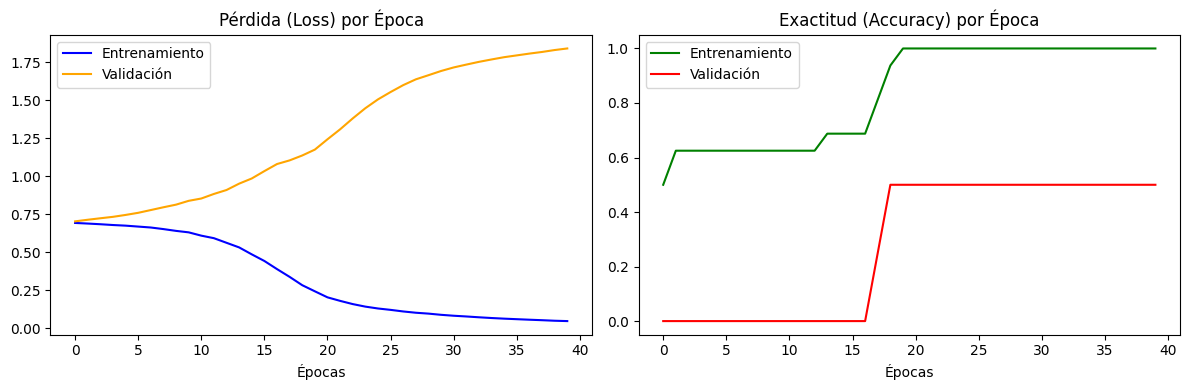

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Historial de Pérdida (Loss)
ax1.plot(historial.history['loss'], color='blue', label='Entrenamiento')
ax1.plot(historial.history['val_loss'], color='orange', label='Validación')
ax1.set_title("Pérdida (Loss) por Época")
ax1.set_xlabel("Épocas")
ax1.legend()

# Historial de Aciertos (Accuracy)
ax2.plot(historial.history['accuracy'], color='green', label='Entrenamiento')
ax2.plot(historial.history['val_accuracy'], color='red', label='Validación')
ax2.set_title("Exactitud (Accuracy) por Época")
ax2.set_xlabel("Épocas")
ax2.legend()

plt.tight_layout()
plt.show()


---
## 7. Predicciones sobre Textos Nuevos
Convertimos reseñas nuevas usando el tokenizador y padding antes de alimentar la red LSTM.


In [13]:
frases_nuevas = [
    "Excelente atención y comida impecable.",
    "La comida estaba fría y la atención muy mala."
]

# 1. Tokenización de las nuevas frases
nuevas_secuencias = tokenizador.texts_to_sequences(frases_nuevas)

# 2. Aplicación de padding
X_nuevos = pad_sequences(nuevas_secuencias, maxlen=longitud_maxima, padding='post')

# 3. Predicción de probabilidades
probabilidades = modelo.predict(X_nuevos)

for i, frase in enumerate(frases_nuevas):
    prob = probabilidades[i][0] * 100
    sentido = "POSITIVO" if prob >= 50 else "NEGATIVO"
    print(f"\nFrase: '{frase}'")
    print(f"Predicción: {sentido} | Confianza de ser Positivo: {prob:.1f}%")


1/1 [==============================] - 1s 510ms/step

Frase: 'Excelente atención y comida impecable.'
Predicción: POSITIVO | Confianza de ser Positivo: 98.7%

Frase: 'La comida estaba fría y la atención muy mala.'
Predicción: POSITIVO | Confianza de ser Positivo: 98.7%


## Consigna de Lectura e Interpretación
**Pregunta para pensar:** ¿Por qué la LSTM tiene una gran ventaja pedagógica al procesar el lenguaje como una secuencia ordenada de palabras en lugar de una simple bolsa de palabras sin orden como en el Cuaderno 04? (Pista: Piensa en frases complejas como *'No estuvo malo, al contrario estuvo genial'*).


La LSTM procesa las palabras en orden una por una  manteniendo memoria de lo que vino antes. Esto le permite entender que en "No estuvo malo, al contrario estuvo genial" el "no" modifica lo que sigue. Con BoW o MLP esa frase sería una bolsa de palabras donde "malo" y "genial" tienen el mismo peso sin contexto, confundiendo al modelo.
